# 01 — Data Exploration

This notebook loads the raw DataCo Supply Chain dataset and explores its structure,
distributions, and patterns before any cleaning or feature engineering.

**Goal**: Understand what we're working with — column types, missing values,
class balance, and initial patterns related to late delivery risk.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Use a consistent style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

## 1.1 Load the Dataset

In [2]:
df = pd.read_csv("../data/raw/DataCoSupplyChainDataset.csv", encoding="latin1")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset shape: 180,519 rows × 53 columns


In [3]:
df.head(3)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


## 1.2 Column Types and Structure

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [5]:
df.dtypes.value_counts()

object     24
float64    15
int64      14
Name: count, dtype: int64

## 1.3 Missing Values

Let's check which columns have missing data and how severe it is.

In [6]:
missing_df = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_df = missing_df[missing_df["Missing"] > 0].sort_values("Percentage", ascending=False)
print(f"Columns with missing values: {len(missing_df)}")
missing_df

Columns with missing values: 4


,Missing,Percentage
Product Description,180519,100.00
Order Zipcode,155679,86.24
Customer Zipcode,3,0.00
Customer Lname,8,0.00


**Observations:**
- `Product Description` is 100% missing — completely useless
- `Order Zipcode` is 86% missing — too sparse to be useful
- `Customer Lname` and `Customer Zipcode` have negligible missing values
- The rest of the dataset is fairly complete

## 1.4 Duplicate Rows

In [7]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes:,} ({n_dupes/len(df)*100:.2f}%)")

Duplicate rows: 0 (0.00%)


## 1.5 Unique Values per Column

In [8]:
df.nunique().sort_values()

Product Description                   0
Customer Password                     1
Product Status                        1
Customer Email                        1
Late_delivery_risk                    2
Customer Country                      2
Customer Segment                      3
Delivery Status                       4
Days for shipment (scheduled)         4
Shipping Mode                         4
Type                                  4
Market                                5
Order Item Quantity                   5
Days for shipping (real)              7
Order Status                          9
Department Id                        11
Department Name                      11
Order Item Discount Rate             18
Order Region                         23
Customer State                       46
Category Name                        50
Product Category Id                  51
Category Id                          51
Order Item Product Price             75
Product Price                        75


## 1.6 Target Variable — Late Delivery Risk

This is the column we want to predict. Let's understand its distribution.

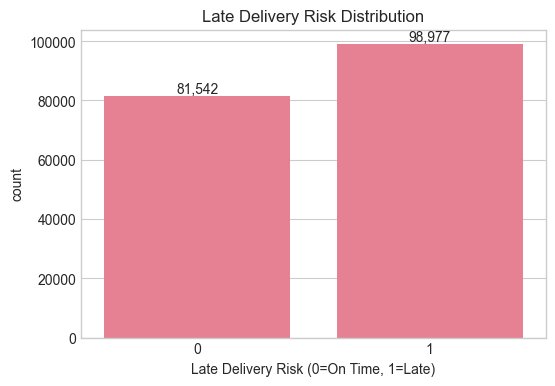


Class distribution:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Late delivery rate: 54.8%


In [9]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x="Late_delivery_risk", data=df)
plt.title("Late Delivery Risk Distribution")

# Add count labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.xlabel("Late Delivery Risk (0=On Time, 1=Late)")
plt.show()

print("\nClass distribution:")
print(df["Late_delivery_risk"].value_counts())
print(f"\nLate delivery rate: {df['Late_delivery_risk'].mean()*100:.1f}%")

**Observation:** The dataset is mildly imbalanced — about 55% late vs 45% on time.
This isn't severe enough to require resampling techniques like SMOTE, but we should
use stratified splitting and pay attention to recall (not just accuracy).

## 1.7 Numerical Feature Distributions

In [10]:
num_cols = df.select_dtypes(include=np.number).columns
print(f"Numerical columns: {len(num_cols)}")
df[num_cols].describe().T

Numerical columns: 29


,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.979980,7.000000,31.520000,64.800003,911.799988
Sales per customer,180519.0,183.107609,120.043670,7.490000,104.379997,163.990005,247.399994,1939.989990
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer Zipcode,180516.0,35921.126914,37542.461122,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Department Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933


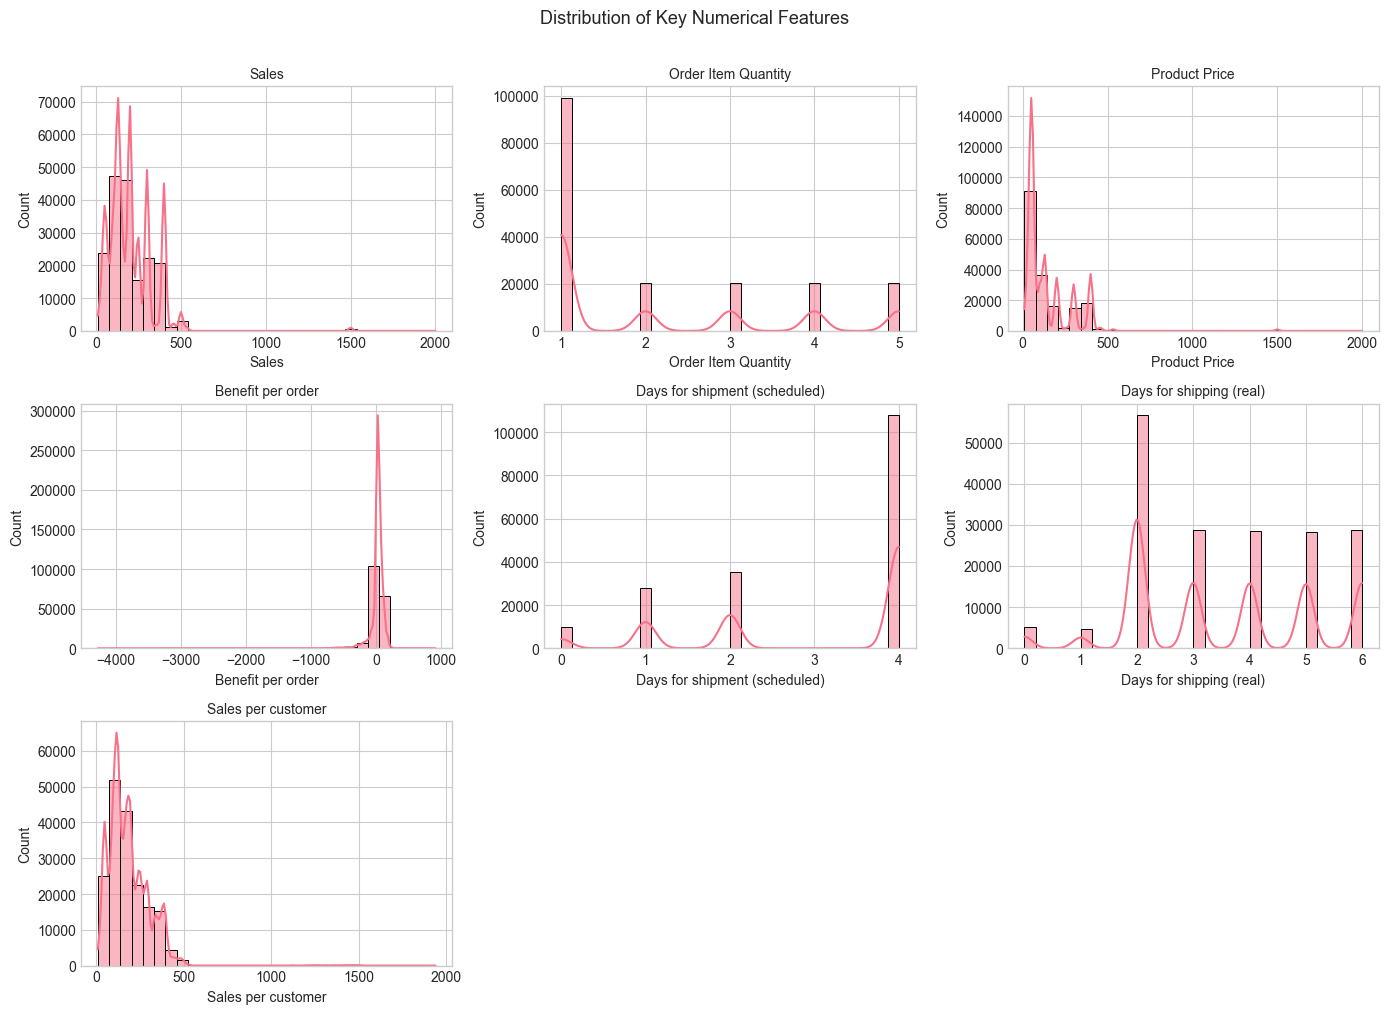

In [11]:
# Distribution plots for key numerical features
key_num = ["Sales", "Order Item Quantity", "Product Price",
           "Benefit per order", "Days for shipment (scheduled)",
           "Days for shipping (real)", "Sales per customer"]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(key_num):
    if col in df.columns and i < len(axes):
        sns.histplot(df[col], kde=True, ax=axes[i], bins=30)
        axes[i].set_title(col, fontsize=10)

# Hide unused subplots
for j in range(len(key_num), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of Key Numerical Features", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 1.8 Correlation Heatmap

<Figure size 1400x1000 with 0 Axes>

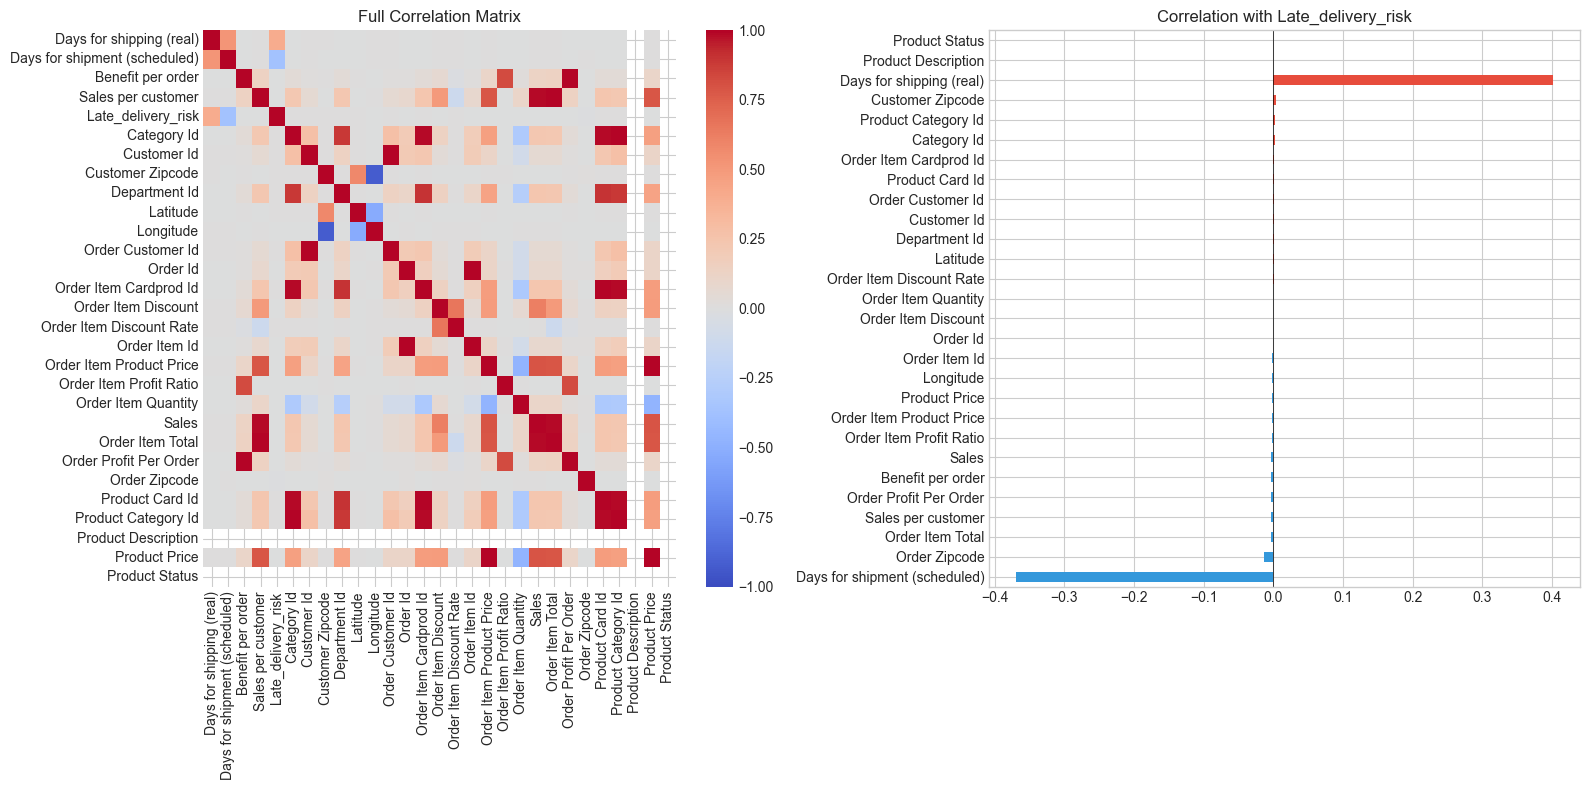

In [12]:
plt.figure(figsize=(14, 10))
corr = df[num_cols].corr()

# Only show correlations with the target
target_corr = corr["Late_delivery_risk"].drop("Late_delivery_risk").sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Full heatmap
sns.heatmap(corr, cmap="coolwarm", annot=False, ax=axes[0],
            center=0, vmin=-1, vmax=1)
axes[0].set_title("Full Correlation Matrix")

# Target correlations
target_corr.plot(kind="barh", ax=axes[1], color=["#e74c3c" if v > 0 else "#3498db" for v in target_corr])
axes[1].set_title("Correlation with Late_delivery_risk")
axes[1].axvline(x=0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

**Observation:** No single numerical feature has a very strong linear correlation
with late delivery risk. This suggests the relationship is likely non-linear,
which is why tree-based models should work better than logistic regression.

## 1.9 Categorical Feature Analysis

### Shipping Mode vs Late Delivery

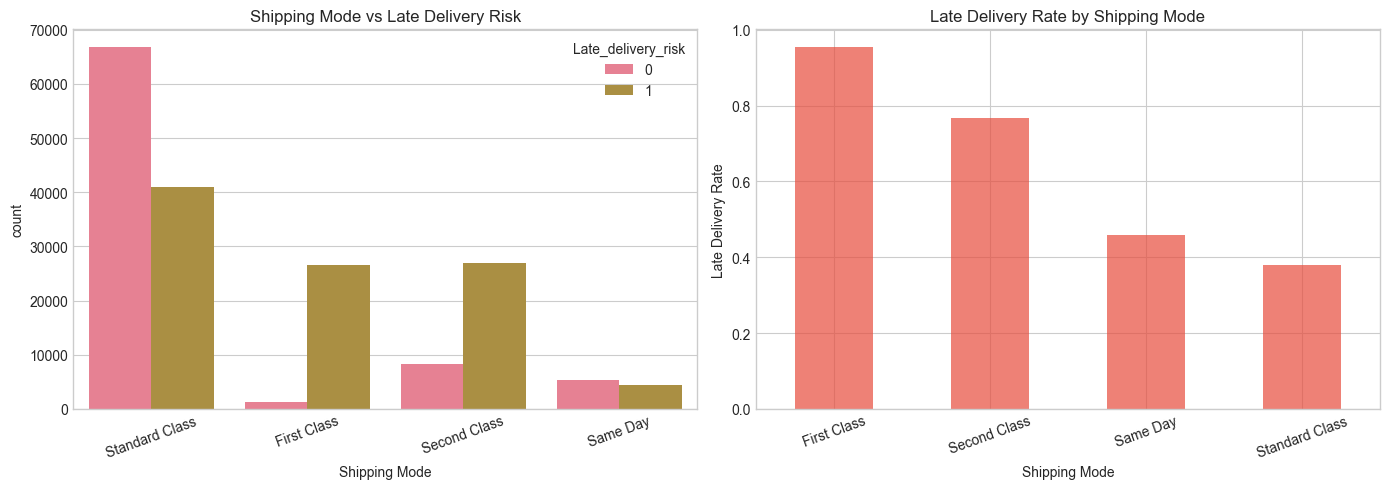

Late delivery rate by shipping mode:
Shipping Mode
First Class       0.953
Second Class      0.766
Same Day          0.457
Standard Class    0.381
Name: Late_delivery_risk, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count by shipping mode
sns.countplot(x="Shipping Mode", hue="Late_delivery_risk", data=df, ax=axes[0])
axes[0].set_title("Shipping Mode vs Late Delivery Risk")
axes[0].tick_params(axis="x", rotation=20)

# Late delivery RATE by shipping mode
delay_by_ship = df.groupby("Shipping Mode")["Late_delivery_risk"].mean().sort_values(ascending=False)
delay_by_ship.plot(kind="bar", ax=axes[1], color="#e74c3c", alpha=0.7)
axes[1].set_title("Late Delivery Rate by Shipping Mode")
axes[1].set_ylabel("Late Delivery Rate")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

print("Late delivery rate by shipping mode:")
print(delay_by_ship.round(3))

### Market vs Late Delivery

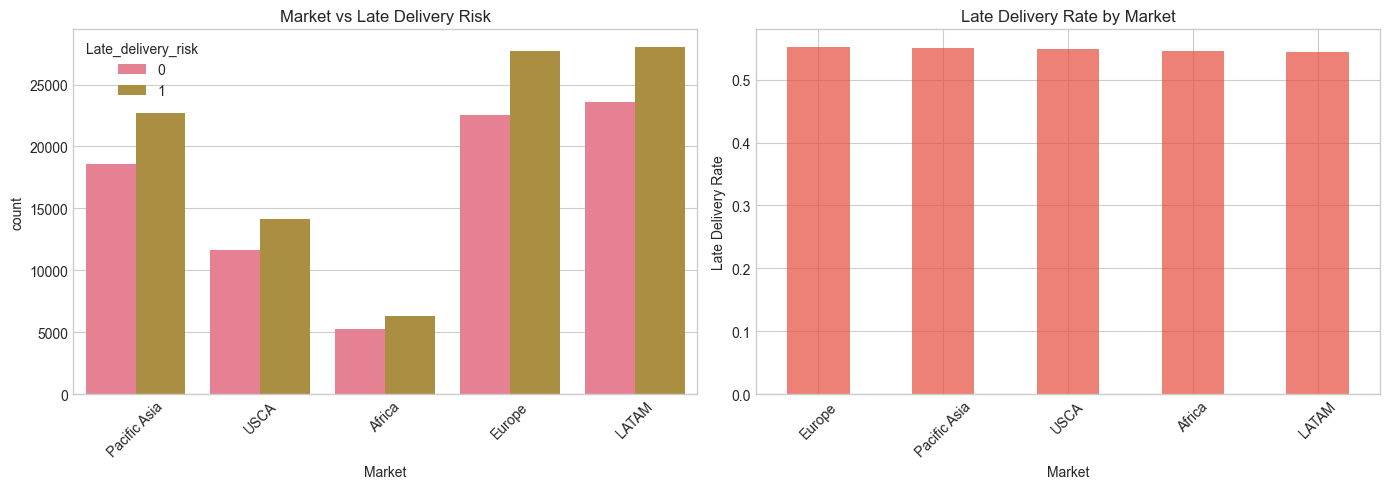

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x="Market", hue="Late_delivery_risk", data=df, ax=axes[0])
axes[0].set_title("Market vs Late Delivery Risk")
axes[0].tick_params(axis="x", rotation=45)

delay_by_market = df.groupby("Market")["Late_delivery_risk"].mean().sort_values(ascending=False)
delay_by_market.plot(kind="bar", ax=axes[1], color="#e74c3c", alpha=0.7)
axes[1].set_title("Late Delivery Rate by Market")
axes[1].set_ylabel("Late Delivery Rate")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Customer Segment vs Late Delivery

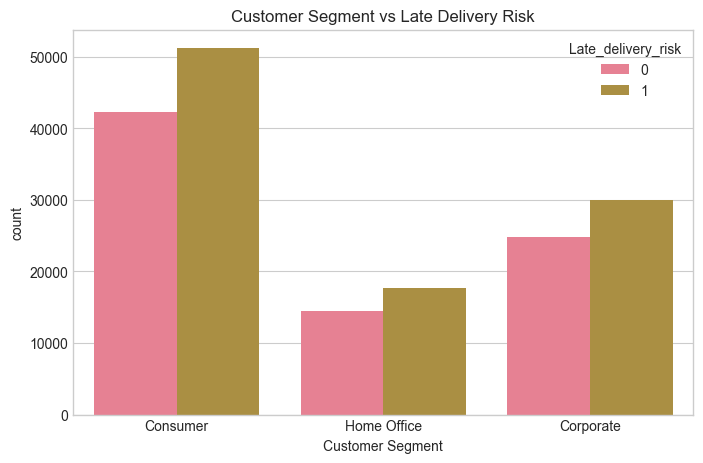

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(x="Customer Segment", hue="Late_delivery_risk", data=df)
plt.title("Customer Segment vs Late Delivery Risk")
plt.show()

### Order Region — Late Delivery Rate

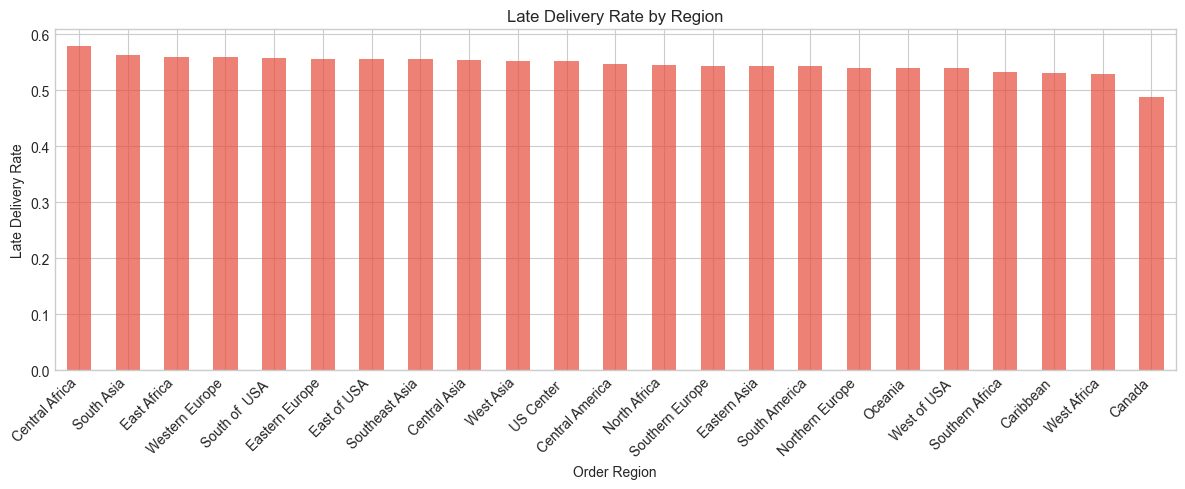

In [16]:
delay_region = (
    df.groupby("Order Region")["Late_delivery_risk"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12, 5))
delay_region.plot(kind="bar", color="#e74c3c", alpha=0.7)
plt.ylabel("Late Delivery Rate")
plt.title("Late Delivery Rate by Region")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Category Name vs Late Delivery

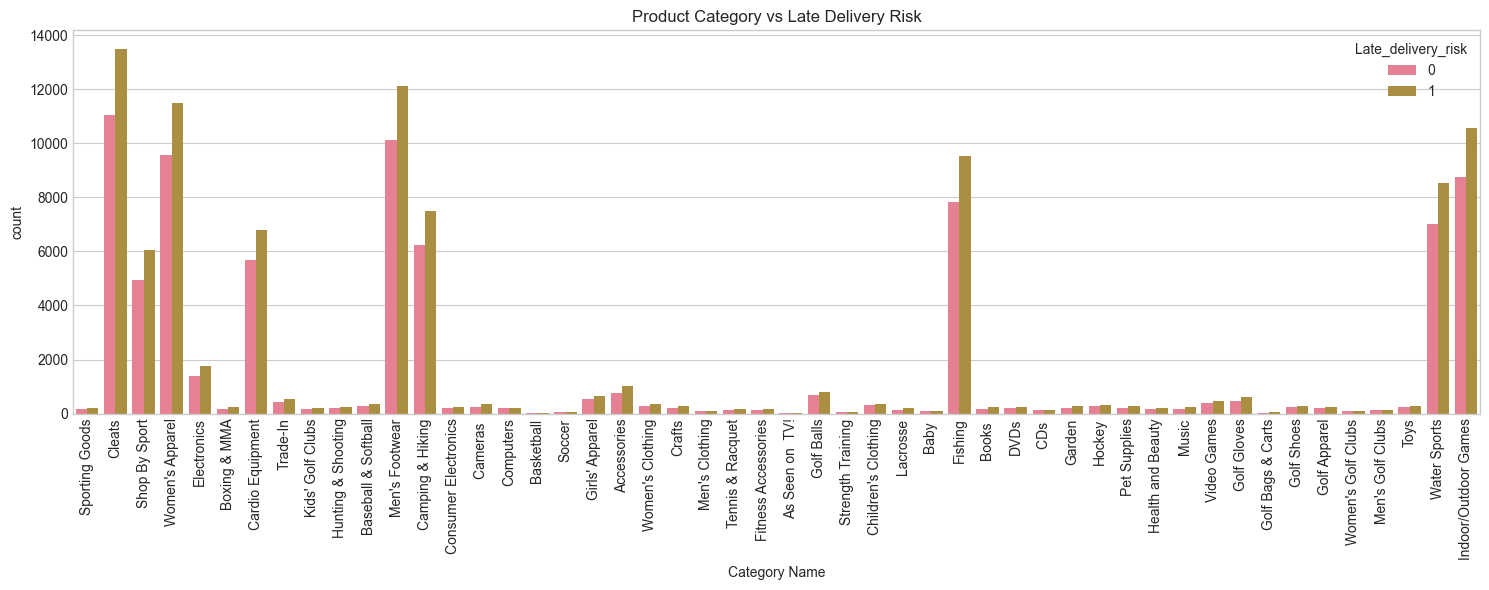

In [17]:
plt.figure(figsize=(15, 6))
sns.countplot(x="Category Name", hue="Late_delivery_risk", data=df)
plt.xticks(rotation=90)
plt.title("Product Category vs Late Delivery Risk")
plt.tight_layout()
plt.show()

## 1.10 Key Feature Relationships

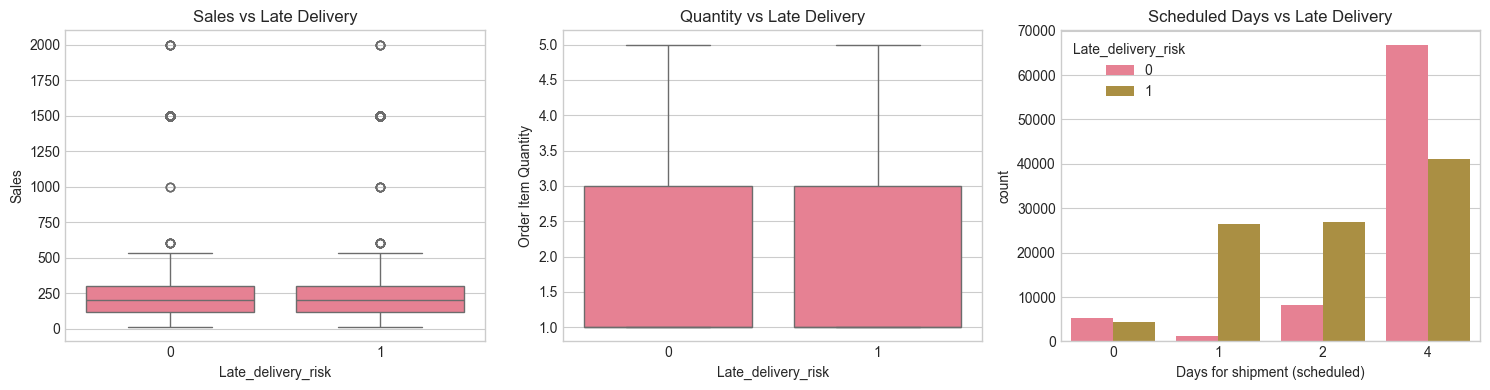

In [18]:
# Sales distribution by delivery risk
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(x="Late_delivery_risk", y="Sales", data=df, ax=axes[0])
axes[0].set_title("Sales vs Late Delivery")

sns.boxplot(x="Late_delivery_risk", y="Order Item Quantity", data=df, ax=axes[1])
axes[1].set_title("Quantity vs Late Delivery")

sns.countplot(x="Days for shipment (scheduled)", hue="Late_delivery_risk",
              data=df, ax=axes[2])
axes[2].set_title("Scheduled Days vs Late Delivery")

plt.tight_layout()
plt.show()

## 1.11 Top Countries by Order Volume

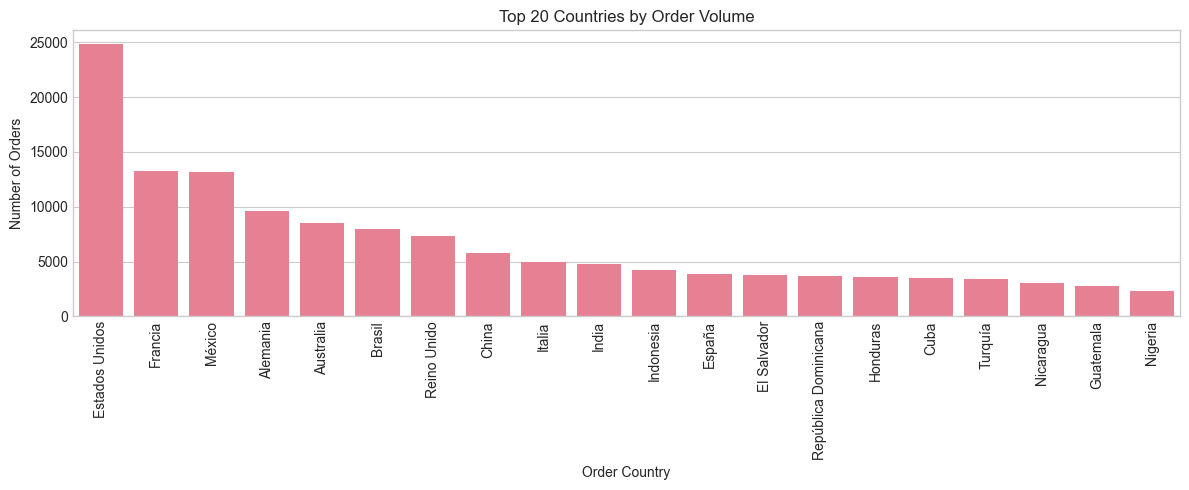

In [19]:
top_countries = df["Order Country"].value_counts().head(20)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_countries.index, y=top_countries.values)
plt.xticks(rotation=90)
plt.title("Top 20 Countries by Order Volume")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

## 1.12 Pairplot of Key Features

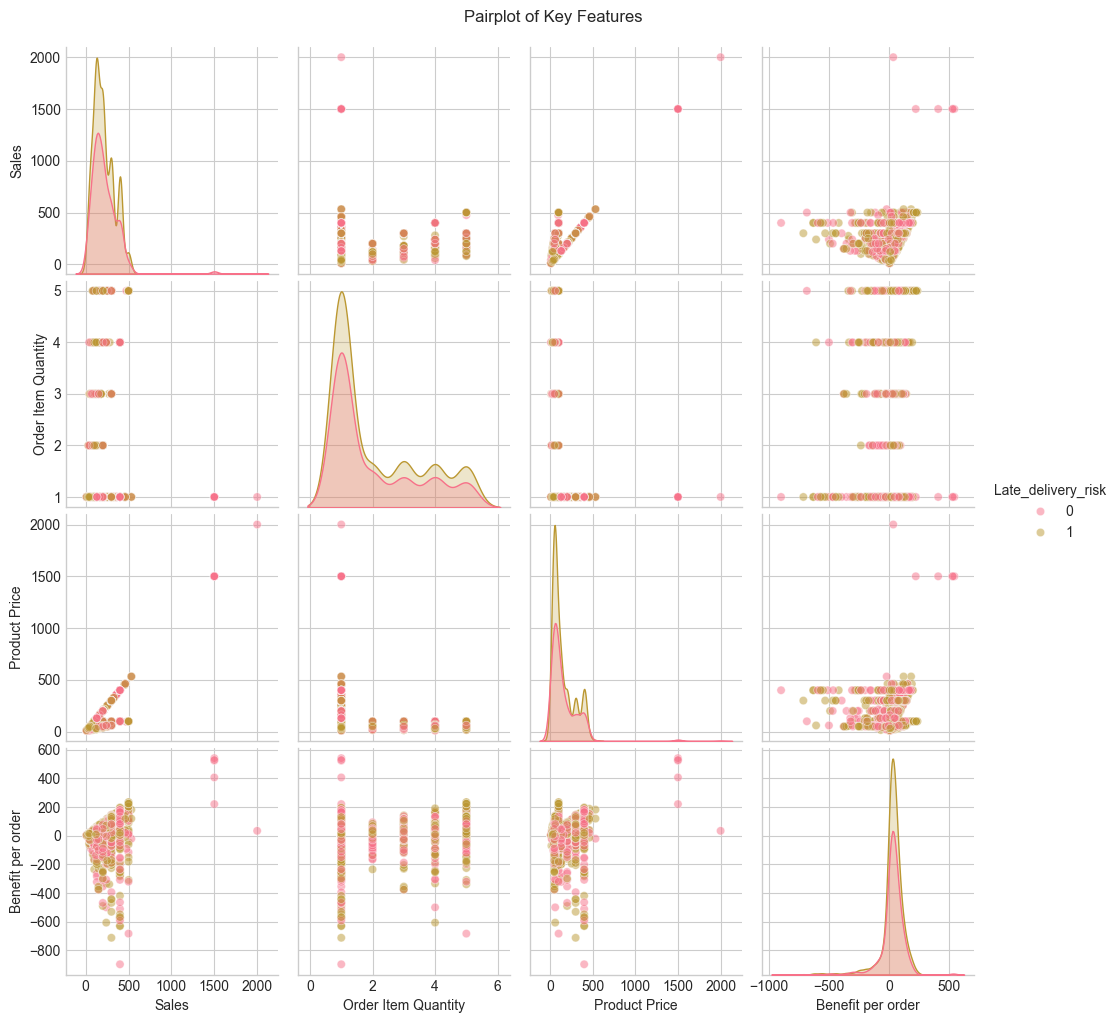

In [20]:
sample = df.sample(2000, random_state=42)

sns.pairplot(
    sample[["Sales", "Order Item Quantity", "Product Price",
            "Benefit per order", "Late_delivery_risk"]],
    hue="Late_delivery_risk",
    plot_kws={"alpha": 0.5}
)
plt.suptitle("Pairplot of Key Features", y=1.02)
plt.show()

## Summary of Exploration

**Key findings so far:**
1. Dataset has 180K+ records across 53 columns — fairly large and complete
2. Target is mildly imbalanced (55% late vs 45% on time)
3. Several columns are leakage risks (`Days for shipping (real)`, `Delivery Status`, `shipping date`)
4. PII columns exist but carry no predictive value (email, password, names)
5. `Product Description` is 100% missing, `Order Zipcode` is 86% missing
6. Shipping Mode appears to be an important factor — some modes have very different delay rates
7. No single numerical feature shows strong linear correlation with the target
8. The data spans multiple years, markets, and product categories

**Next step**: Data preprocessing (cleaning, leakage removal, date extraction)